# Geospatial Coffee Analysis

This notebook focuses on the geographic side of the project: how location, regional weather patterns, and spatial clustering relate to coffee commodity price regimes.

Important limitation: `Close_USD_60kg` is a market-level coffee price and appears to be repeated across locations on the same day. That means coordinates do **not** determine a unique local price on a given date. A better geospatial question is:

- Which locations and spatial weather patterns are associated with high-price periods?
- Do some coordinate ranges experience weather anomalies more often when coffee prices are elevated?
- Can geography plus weather help classify whether the market is in a high-price regime?


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import griddata
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)

ROOT = Path.cwd()
if not (ROOT / 'Coffee_Data_Set.csv').exists():
    ROOT = ROOT.parent

DATASET_PATH = ROOT / 'Coffee_Data_Set.csv'
df = pd.read_csv(DATASET_PATH, parse_dates=['Date'])

numeric_columns = [
    'LON', 'LAT', 'Temp_Max', 'Temp_Min', 'Humidity',
    'Solar_Radiation', 'Precipitation_mm', 'Close_USD_60kg', 'brl', 'cny', 'mxn'
]

df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
df.head()

,LON,LAT,YEAR,MM,DD,DOY,Date,Temp_Max,Temp_Min,Humidity,Solar_Radiation,Precipitation_mm,Location,Close_USD_60kg,Is_Weekend,Is_Interpolated,brl,cny,mxn
0,-40.9743,-20.0421,2000,1,3,3,2000-01-03,24.51,20.01,89.29,16.17,2.61,Brazil_Espirito_Santo_Afonso,154.102705,False,False,1.805,8.2798,9.4015
1,-41.2502,-20.3633,2000,1,3,3,2000-01-03,25.16,19.90,86.10,16.84,2.90,Brazil_Espirito_Santo_Conceicao,154.102705,False,False,1.805,8.2798,9.4015
2,-42.3906,-17.9910,2000,1,3,3,2000-01-03,26.47,19.33,86.07,22.78,5.11,Brazil_Minas_Gerais_Aqua_Boa,154.102705,False,False,1.805,8.2798,9.4015
3,-46.1628,-20.2579,2000,1,3,3,2000-01-03,22.97,19.12,91.41,5.73,55.08,Brazil_Minas_Gerais_Manhuacu,154.102705,False,False,1.805,8.2798,9.4015
4,-46.9923,-18.9349,2000,1,3,3,2000-01-03,22.66,18.48,92.03,9.82,48.38,Brazil_Minas_Gerais_Patrocinio,154.102705,False,False,1.805,8.2798,9.4015


## 1. Basic Geographic Coverage

In [2]:
print(f'Rows: {len(df):,}')
print(f'Locations: {df["Location"].nunique():,}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')

location_points = (
    df.groupby('Location', as_index=False)
    .agg({
        'LON': 'first',
        'LAT': 'first',
        'Temp_Max': 'mean',
        'Temp_Min': 'mean',
        'Humidity': 'mean',
        'Precipitation_mm': 'mean',
    })
)

location_points.head()

Rows: 233,000
Locations: 25
Date range: 2000-01-03 to 2025-07-09


,Location,LON,LAT,Temp_Max,Temp_Min,Humidity,Precipitation_mm
0,Brazil_Espirito_Santo_Afonso,-40.9743,-20.0421,28.261224,17.255857,77.425737,2.979250
1,Brazil_Espirito_Santo_Conceicao,-41.2502,-20.3633,27.342638,16.995511,78.749172,3.148545
2,Brazil_Minas_Gerais_Aqua_Boa,-42.3906,-17.9910,29.126409,17.179467,71.376330,2.711495
3,Brazil_Minas_Gerais_Manhuacu,-46.1628,-20.2579,27.153571,16.305996,71.864791,3.357127
4,Brazil_Minas_Gerais_Patrocinio,-46.9923,-18.9349,27.590547,16.156531,71.223442,3.332626


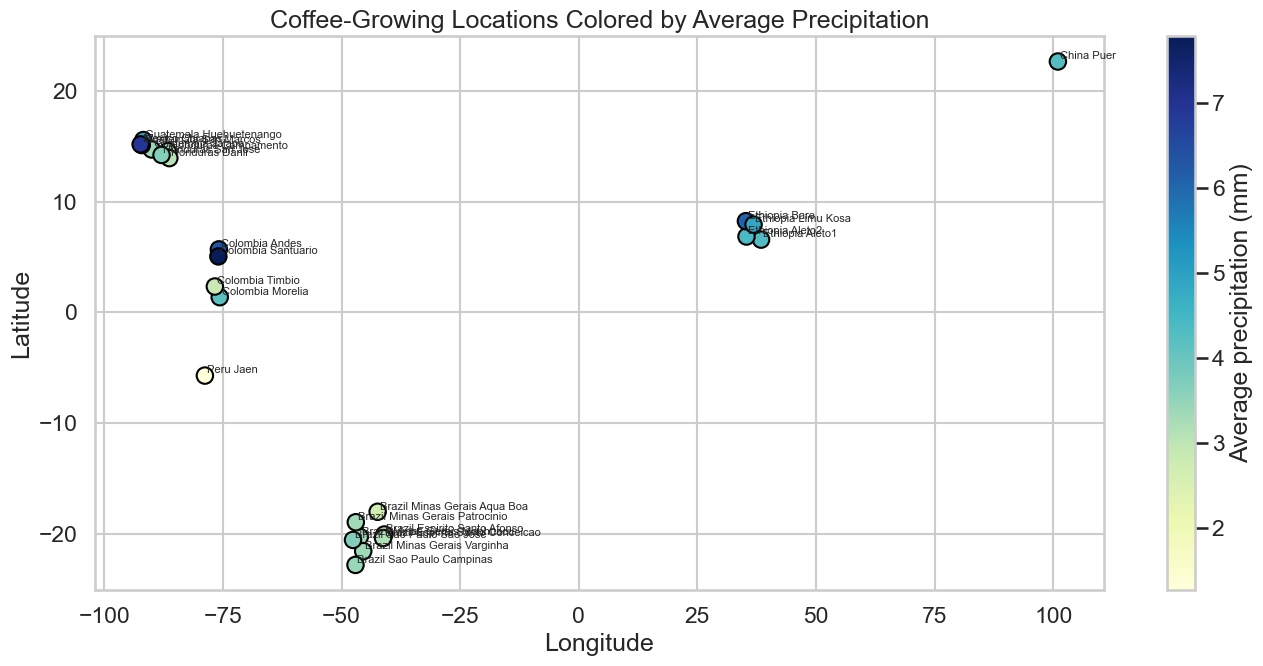

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(
    location_points['LON'],
    location_points['LAT'],
    c=location_points['Precipitation_mm'],
    s=140,
    cmap='YlGnBu',
    edgecolor='black',
)
ax.set_title('Coffee-Growing Locations Colored by Average Precipitation')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.colorbar(scatter, ax=ax, label='Average precipitation (mm)')

for _, row in location_points.iterrows():
    ax.text(row['LON'] + 0.4, row['LAT'] + 0.2, row['Location'].replace('_', ' '), fontsize=8)

plt.tight_layout()
plt.show()

## 2. Create High-Price vs Low-Price Regimes

Because price is shared across locations on a date, we classify each date into a market regime and then study how the spatial weather field differs across regimes.

In [4]:
daily_price = (
    df.groupby('Date', as_index=False)['Close_USD_60kg']
    .first()
    .sort_values('Date')
)

price_threshold = daily_price['Close_USD_60kg'].quantile(0.75)
daily_price['High_Price_Regime'] = (daily_price['Close_USD_60kg'] >= price_threshold).astype(int)

df = df.merge(daily_price[['Date', 'High_Price_Regime']], on='Date', how='left')

print(f'High-price threshold: {price_threshold:.2f} USD per 60 kg')
daily_price.head()

High-price threshold: 220.92 USD per 60 kg


,Date,Close_USD_60kg,High_Price_Regime
0,2000-01-03,154.102705,0
1,2000-01-04,153.772012,0
2,2000-01-05,156.880520,0
3,2000-01-06,154.565672,0
4,2000-01-07,150.994198,0


## 3. Which Locations See the Biggest Weather Shift During High-Price Periods?

In [5]:
location_regime = (
    df.groupby(['Location', 'High_Price_Regime'], as_index=False)
    .agg({
        'LON': 'first',
        'LAT': 'first',
        'Temp_Max': 'mean',
        'Temp_Min': 'mean',
        'Humidity': 'mean',
        'Precipitation_mm': 'mean',
    })
)

pivot_precip = location_regime.pivot(index='Location', columns='High_Price_Regime', values='Precipitation_mm')
pivot_temp = location_regime.pivot(index='Location', columns='High_Price_Regime', values='Temp_Max')

shift_summary = pd.DataFrame({
    'Precip_Shift_HighMinusLow': pivot_precip.get(1) - pivot_precip.get(0),
    'TempMax_Shift_HighMinusLow': pivot_temp.get(1) - pivot_temp.get(0),
}).reset_index()

shift_summary.sort_values('Precip_Shift_HighMinusLow', ascending=False).head(10)

,Location,Precip_Shift_HighMinusLow,TempMax_Shift_HighMinusLow
11,Colombia_Santuario,1.426567,-0.246295
9,Colombia_Andes,1.167309,-0.109725
22,Honduras_San_Jose,1.045870,-0.645270
10,Colombia_Morelia,1.012558,-0.560850
12,Colombia_Timbio,0.959767,-0.450601
21,Honduras_Danli,0.884531,-0.704488
13,Ethiopia_Aleto1,0.877134,-0.478039
14,Ethiopia_Aleto2,0.754258,-0.347957
20,Honduras_Campamento,0.700589,-0.456162
15,Ethiopia_Bare,0.561202,-0.326436


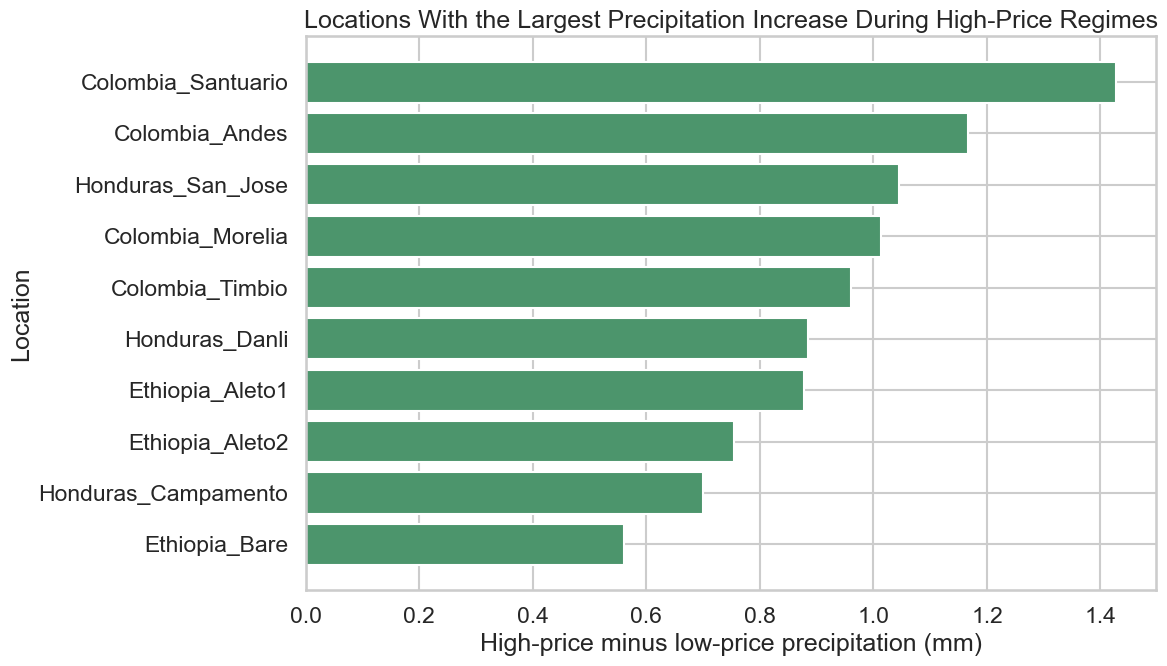

In [6]:
plot_df = shift_summary.sort_values('Precip_Shift_HighMinusLow').tail(10)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_df['Location'], plot_df['Precip_Shift_HighMinusLow'], color='#4c956c')
ax.set_title('Locations With the Largest Precipitation Increase During High-Price Regimes')
ax.set_xlabel('High-price minus low-price precipitation (mm)')
ax.set_ylabel('Location')
plt.tight_layout()
plt.show()

## 4. Spatial Interpolation Example

This is not full kriging. It is a quick geospatial interpolation using `scipy.interpolate.griddata` so the notebook can show a spatial surface without depending on GIS-specific libraries.

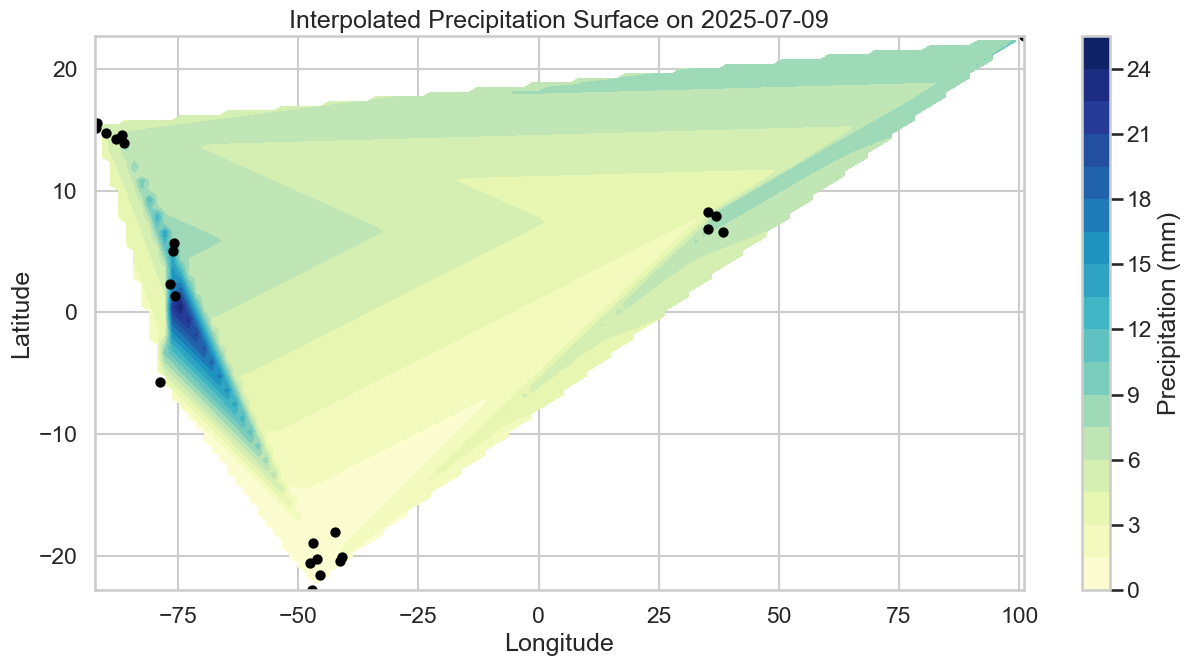

In [7]:
snapshot_date = df['Date'].max()
snapshot = df[df['Date'] == snapshot_date].dropna(subset=['LON', 'LAT', 'Precipitation_mm']).copy()

grid_lon = np.linspace(snapshot['LON'].min(), snapshot['LON'].max(), 120)
grid_lat = np.linspace(snapshot['LAT'].min(), snapshot['LAT'].max(), 120)
mesh_lon, mesh_lat = np.meshgrid(grid_lon, grid_lat)

grid_precip = griddata(
    points=snapshot[['LON', 'LAT']].to_numpy(),
    values=snapshot['Precipitation_mm'].to_numpy(),
    xi=(mesh_lon, mesh_lat),
    method='linear',
)

fig, ax = plt.subplots(figsize=(13, 7))
contour = ax.contourf(mesh_lon, mesh_lat, grid_precip, levels=18, cmap='YlGnBu')
ax.scatter(snapshot['LON'], snapshot['LAT'], c='black', s=35)
ax.set_title(f'Interpolated Precipitation Surface on {snapshot_date.date()}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.colorbar(contour, ax=ax, label='Precipitation (mm)')
plt.tight_layout()
plt.show()

## 5. Coordinate-Only vs Coordinate+Weather Model

This section directly tests the idea behind the question, `Will coffee prices go up depending on the coordinates in which it is harvested?`

A better framing is: can coordinates, or coordinates plus local weather, help classify whether the market is in a high-price regime?

In [8]:
model_df = df[[
    'LON', 'LAT', 'Temp_Max', 'Temp_Min', 'Humidity', 'Solar_Radiation',
    'Precipitation_mm', 'High_Price_Regime'
]].copy()

train_df, test_df = train_test_split(
    model_df,
    test_size=0.25,
    random_state=42,
    stratify=model_df['High_Price_Regime'],
)

def fit_logistic(feature_columns):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), feature_columns)
        ]
    )

    model = Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=2000))
    ])

    model.fit(train_df[feature_columns], train_df['High_Price_Regime'])
    probs = model.predict_proba(test_df[feature_columns])[:, 1]
    preds = (probs >= 0.5).astype(int)
    auc = roc_auc_score(test_df['High_Price_Regime'], probs)
    report = classification_report(test_df['High_Price_Regime'], preds, output_dict=True)
    return auc, report, model

coord_auc, coord_report, coord_model = fit_logistic(['LON', 'LAT'])
full_auc, full_report, full_model = fit_logistic([
    'LON', 'LAT', 'Temp_Max', 'Temp_Min', 'Humidity', 'Solar_Radiation', 'Precipitation_mm'
])

print('Coordinate-only ROC AUC:', round(coord_auc, 3))
print('Coordinate+weather ROC AUC:', round(full_auc, 3))

Coordinate-only ROC AUC: 0.495
Coordinate+weather ROC AUC: 0.516


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [9]:
comparison = pd.DataFrame({
    'Model': ['Coordinates only', 'Coordinates + weather'],
    'ROC_AUC': [coord_auc, full_auc],
    'Precision_HighPrice': [coord_report['1']['precision'], full_report['1']['precision']],
    'Recall_HighPrice': [coord_report['1']['recall'], full_report['1']['recall']],
})
comparison

,Model,ROC_AUC,Precision_HighPrice,Recall_HighPrice
0,Coordinates only,0.494767,0.0,0.0
1,Coordinates + weather,0.516352,0.0,0.0


/var/folders/t0/cl4mx7656030fy5dm2t2jwsr0000gn/T/ipykernel_42606/2382268719.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x='Model', y='ROC_AUC', palette=['#2f6690', '#4c956c'], ax=ax)


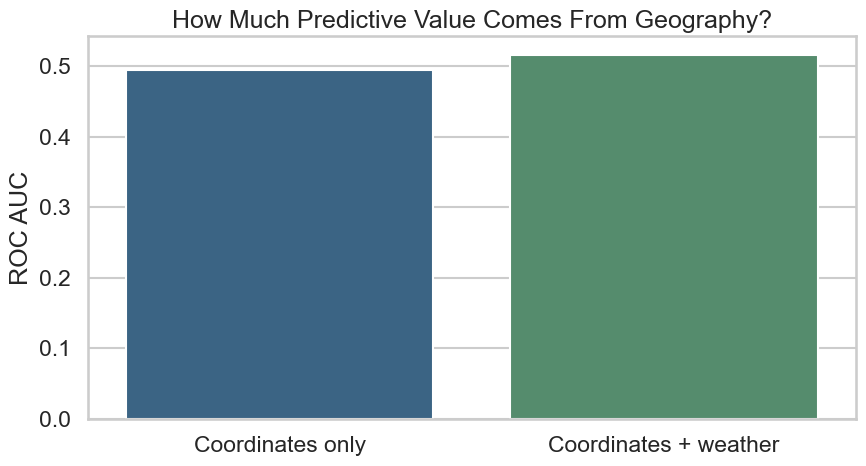

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=comparison, x='Model', y='ROC_AUC', palette=['#2f6690', '#4c956c'], ax=ax)
ax.set_title('How Much Predictive Value Comes From Geography?')
ax.set_ylabel('ROC AUC')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 6. Unsupervised Spatial Clustering of Coffee Regions

In [11]:
cluster_features = location_points[['LON', 'LAT', 'Temp_Max', 'Humidity', 'Precipitation_mm']].copy()
scaled = StandardScaler().fit_transform(cluster_features)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
location_points['Cluster'] = kmeans.fit_predict(scaled).astype(str)

location_points[['Location', 'Cluster', 'LON', 'LAT', 'Precipitation_mm']].head()

,Location,Cluster,LON,LAT,Precipitation_mm
0,Brazil_Espirito_Santo_Afonso,3,-40.9743,-20.0421,2.979250
1,Brazil_Espirito_Santo_Conceicao,3,-41.2502,-20.3633,3.148545
2,Brazil_Minas_Gerais_Aqua_Boa,3,-42.3906,-17.9910,2.711495
3,Brazil_Minas_Gerais_Manhuacu,3,-46.1628,-20.2579,3.357127
4,Brazil_Minas_Gerais_Patrocinio,3,-46.9923,-18.9349,3.332626


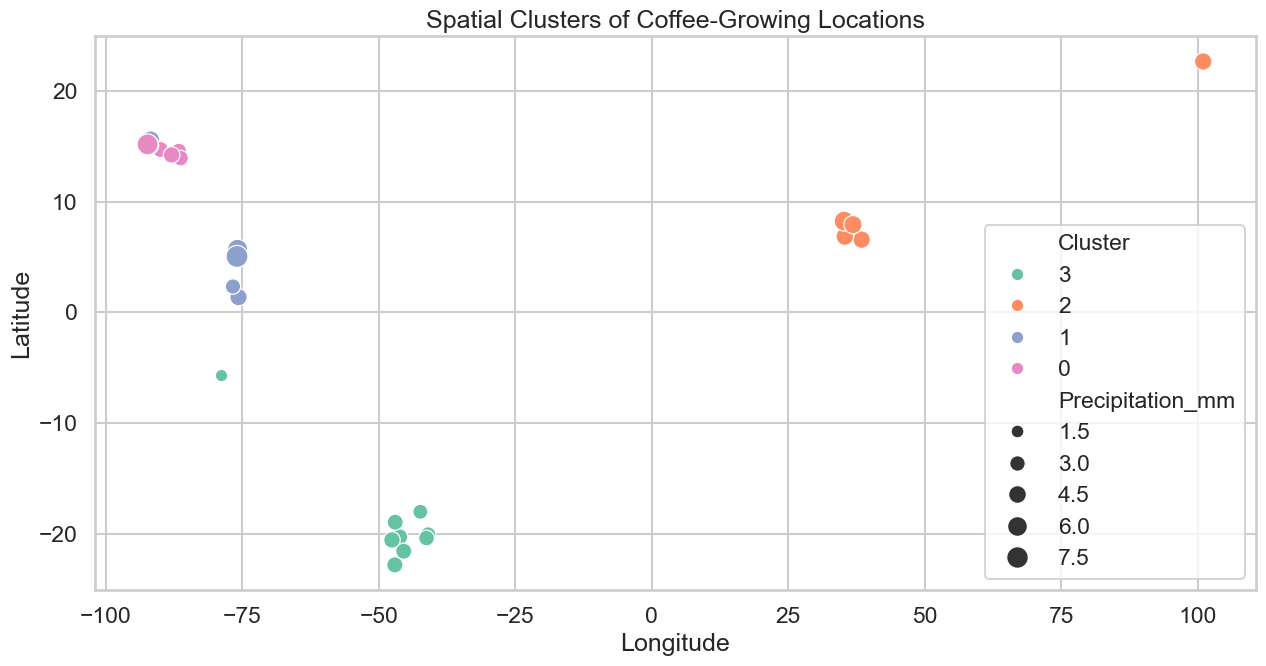

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))
sns.scatterplot(
    data=location_points,
    x='LON',
    y='LAT',
    hue='Cluster',
    size='Precipitation_mm',
    sizes=(80, 250),
    palette='Set2',
    ax=ax,
)
ax.set_title('Spatial Clusters of Coffee-Growing Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 7. Interpreting the Results

Suggested project language:

- Coordinates alone usually should not be interpreted as causing higher coffee prices.
- The stronger interpretation is that spatially distributed weather conditions across major producing regions help characterize market environments associated with higher prices.
- If the coordinate-only model performs weakly while the coordinate+weather model improves, that supports the idea that **regional climate context**, not location by itself, is the more meaningful geospatial driver in this dataset.